# EDA 04: Pacientes con diabetes

## improts

In [195]:
# imports:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

In [196]:
df = pd.read_csv("../data/raw/diabetes-data.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Paso 1: **Planteamiento del problema**

* **Planteamiento:** 
* **Objetivo:** 

## Paso 2: Exploración y limpieza de datos

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Observaciones:**

> DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 768 filas y 9 columnas  
> * Los datos que aporta el datset son diez columnas de tipo numérico (enteros y decimales) y séis columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(3), int64(7), object(6)`

In [198]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Observaciones:**

> VAOLRES ESTADÍSTICOS:

## Paso 3: Análisis Descriptivo

In [199]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

* **Descripción del conjunto de variables que aporta el dataset:**

- `Pregnancies`. Número de embarazos del paciente (numérico)
- `Glucose`. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- `BloodPressure`. Presión arterial diastólica (medida en mm Hg) (numérico)
- `SkinThickness`. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- `Insulin`. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- `BMI`. Índice de masa corporal (numérico)
- `DiabetesPedigreeFunction`. Función de pedigrí de diabetes (numérico)
- `Age`. Edad del paciente (numérico)
- `Outcome`. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

1. COLUMNAS Y CARACTERÍSTICAS DE LAS VARIABLES: NUMÉRICOS Y CATEGÓRICOS

NUMÉRICAS:

> Continuas:
> Discretas:

CATEGÓRICAS

* **Variable target** 
> ``Outcome``, es la variable que nos da el resultado del planteamiento del problema, si un paciente es diabetico o no. No se indica el tipo de diabetes de la persona.

* **Correlaciones**

### * histograma

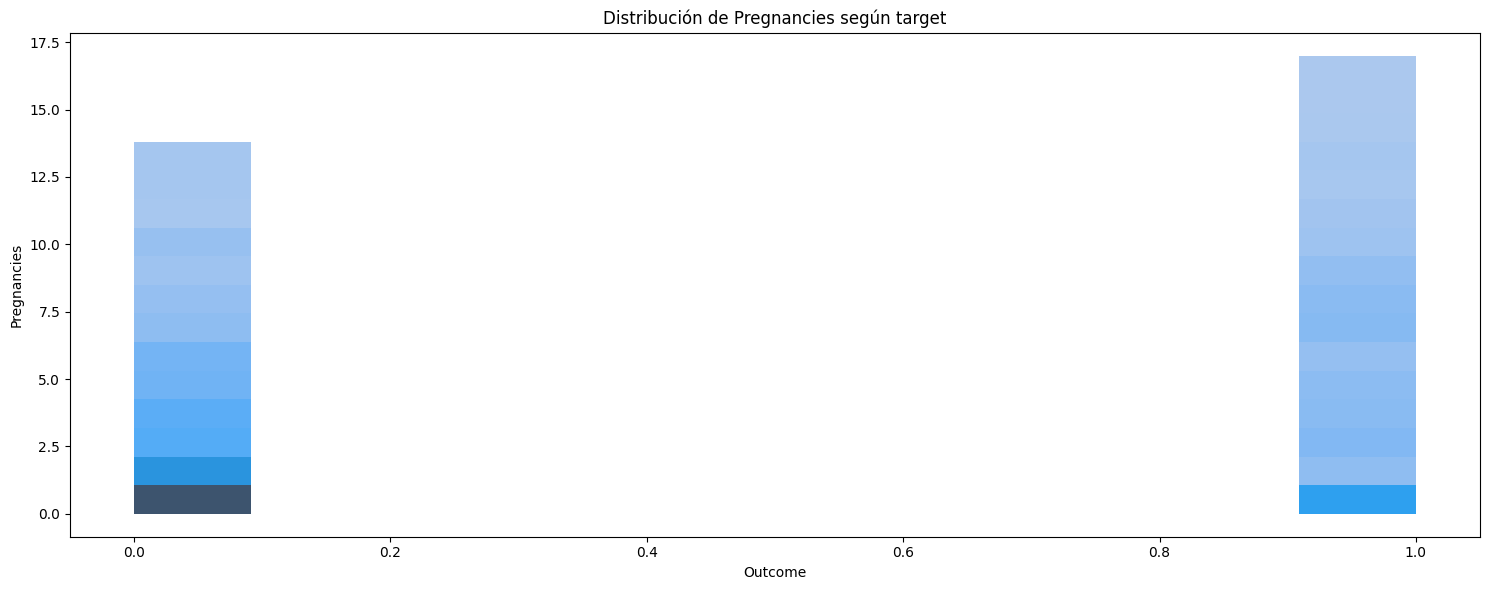

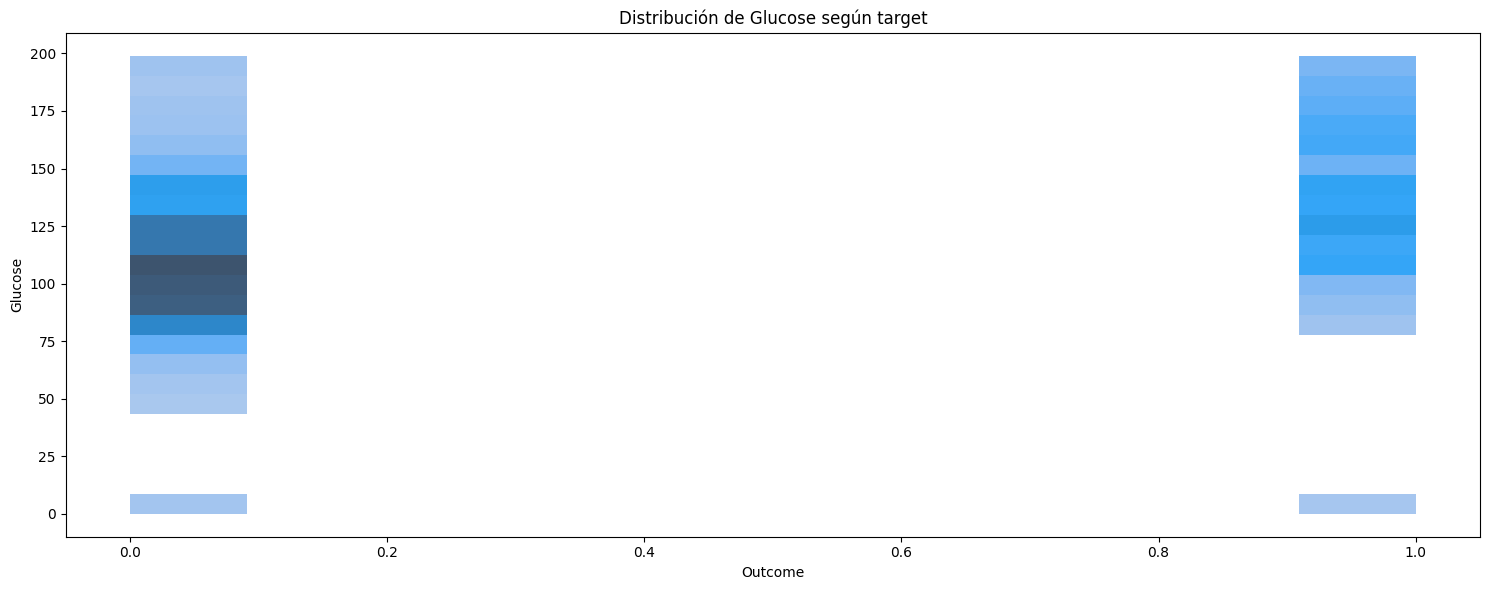

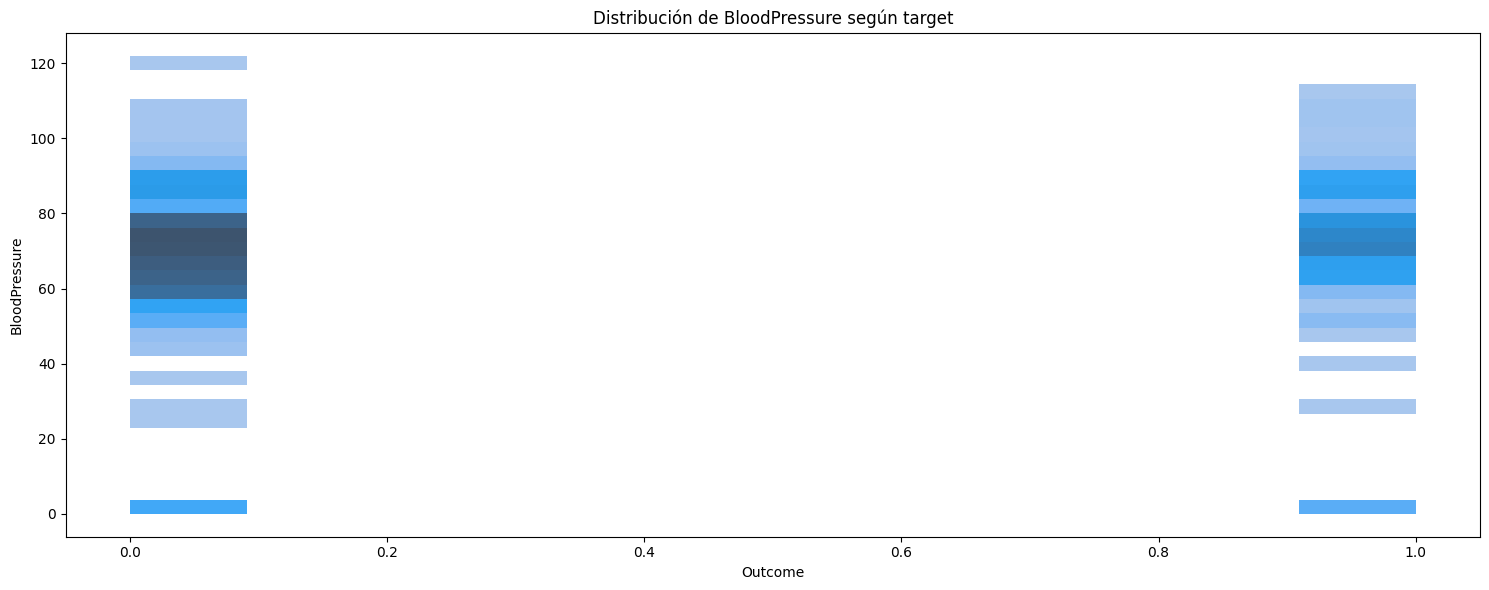

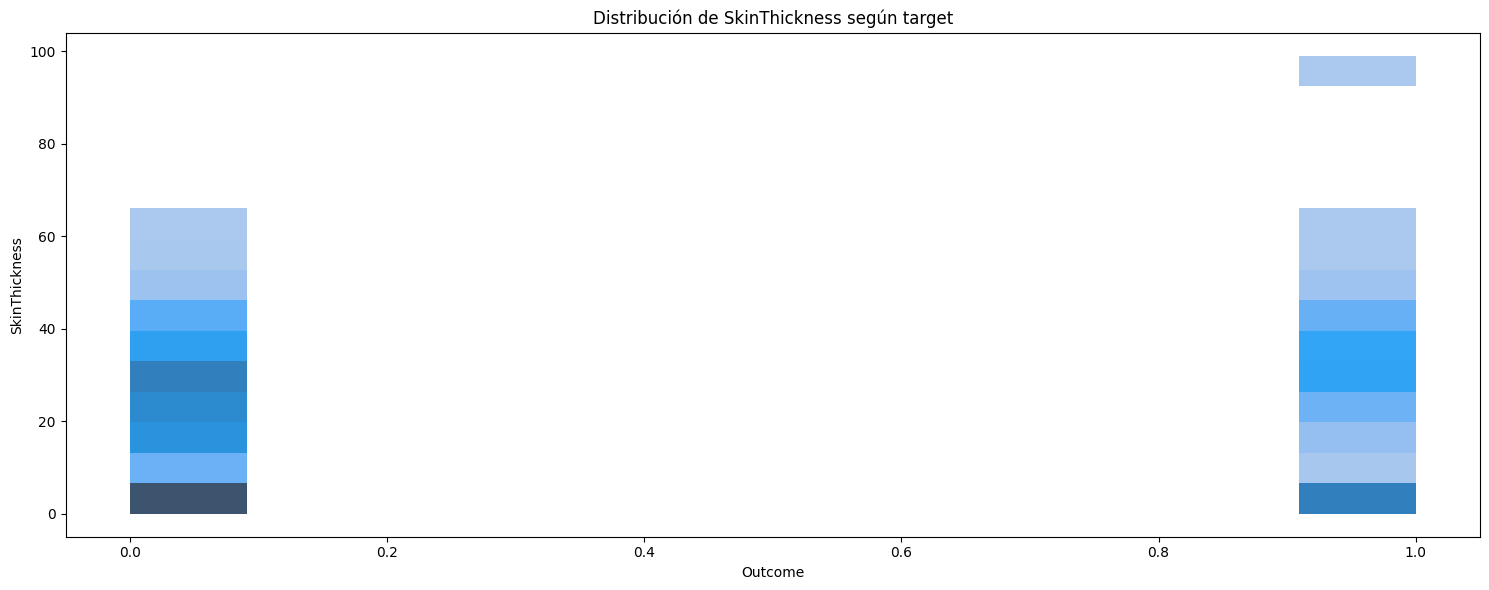

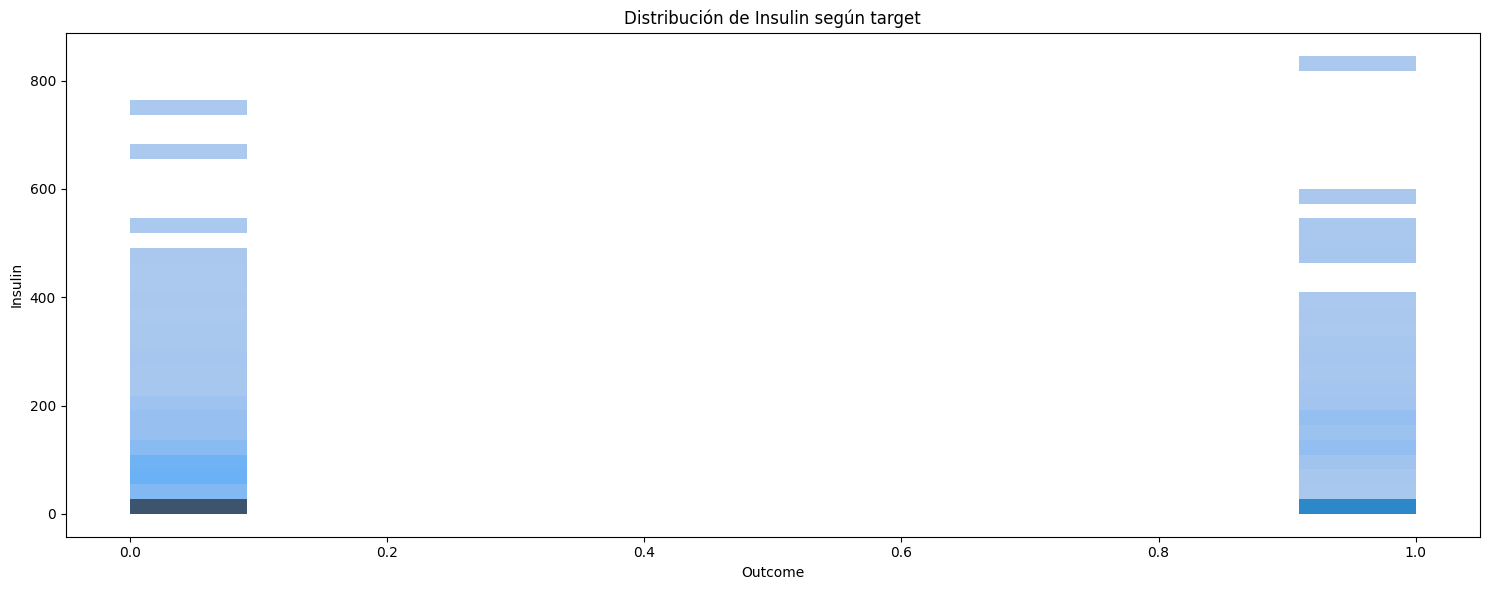

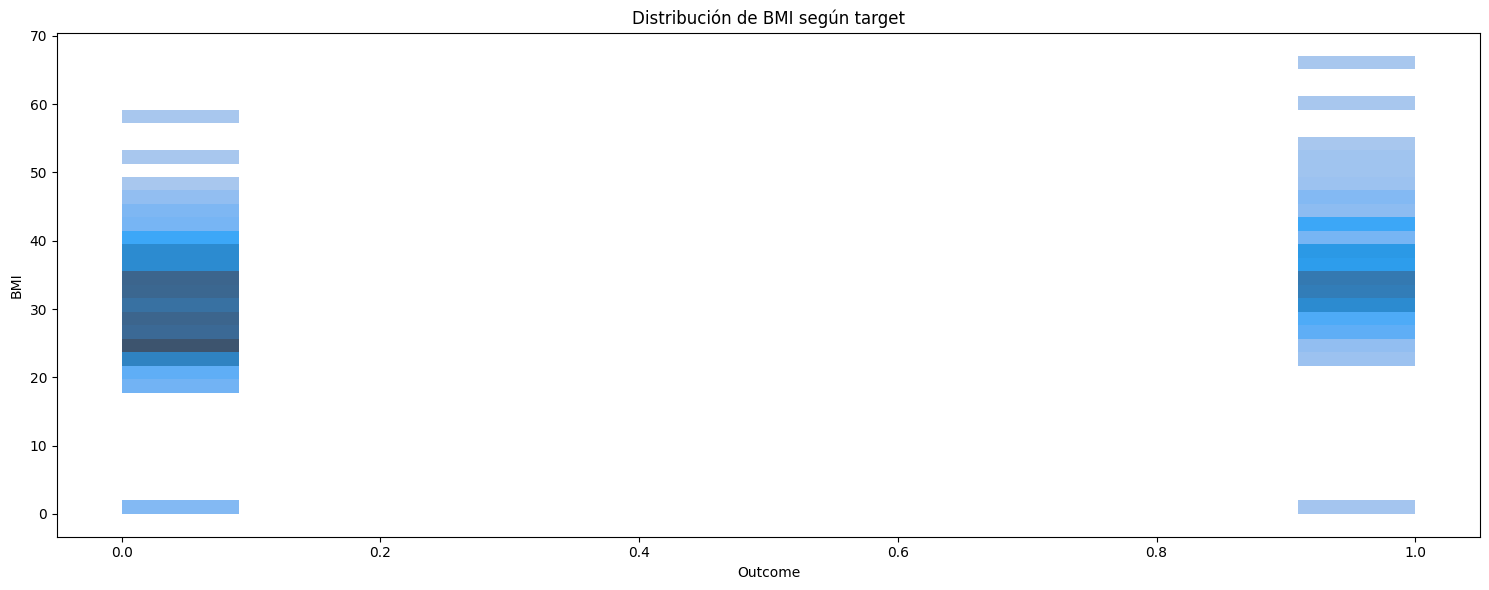

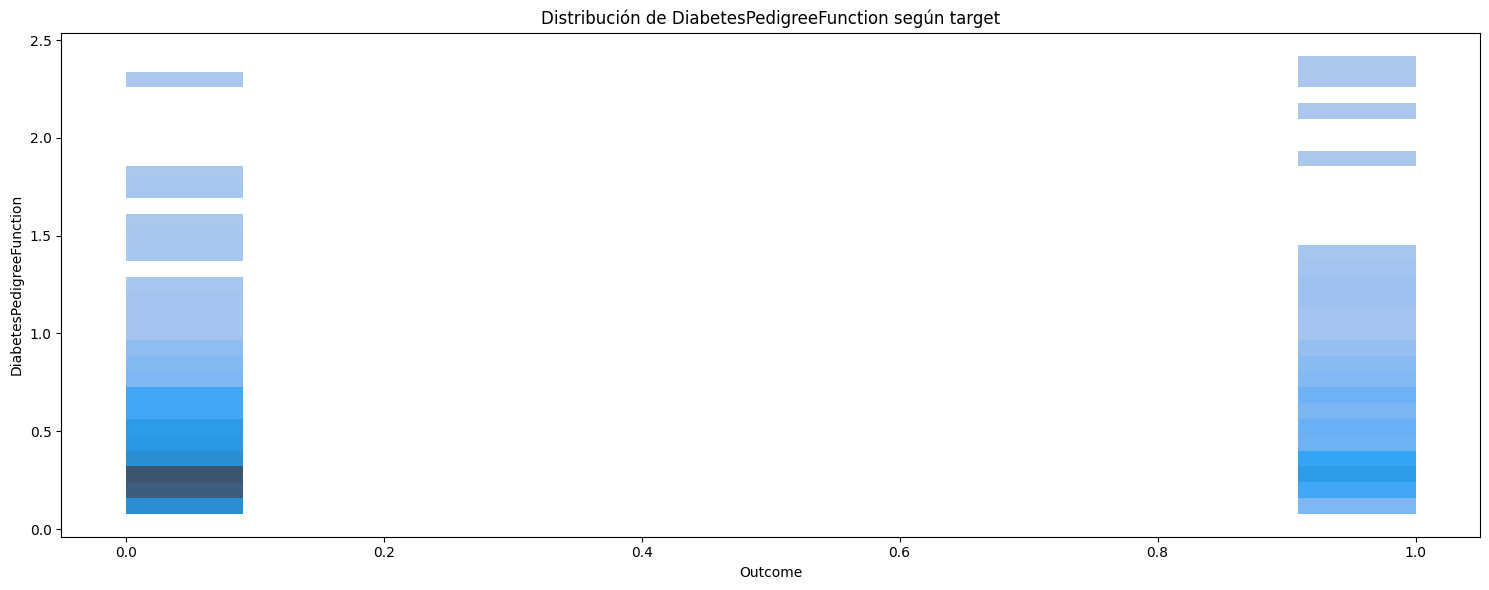

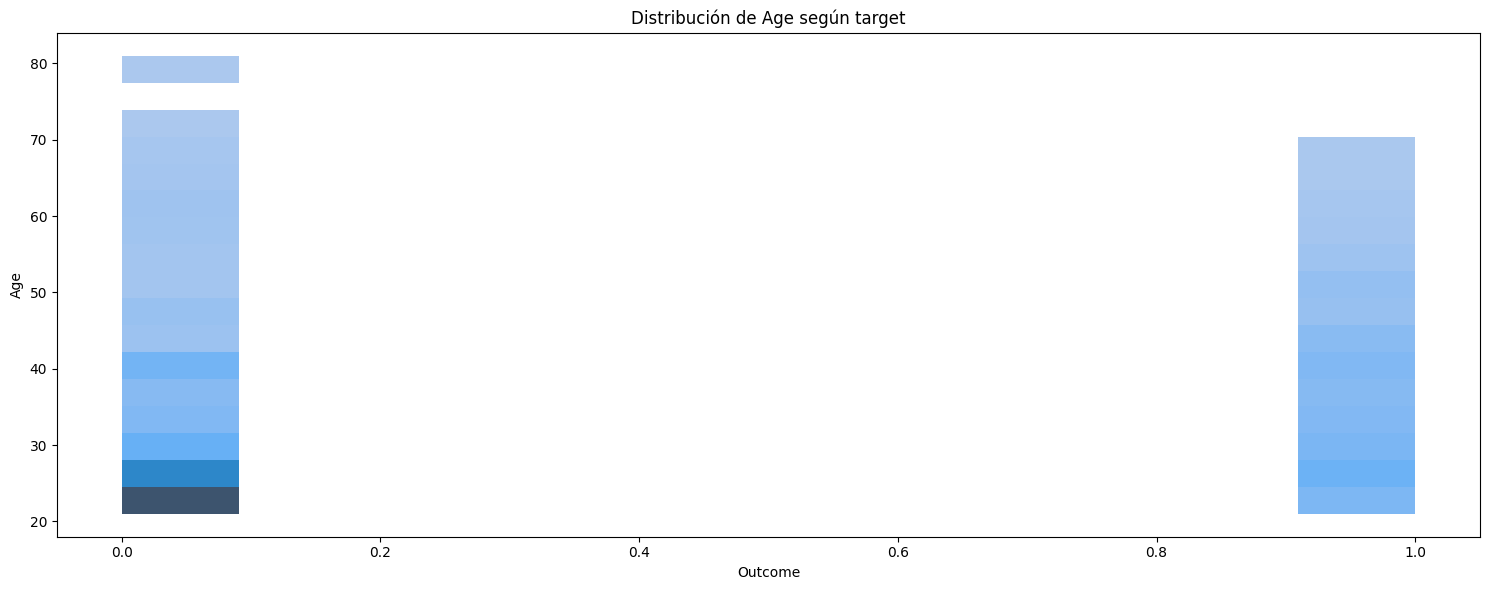

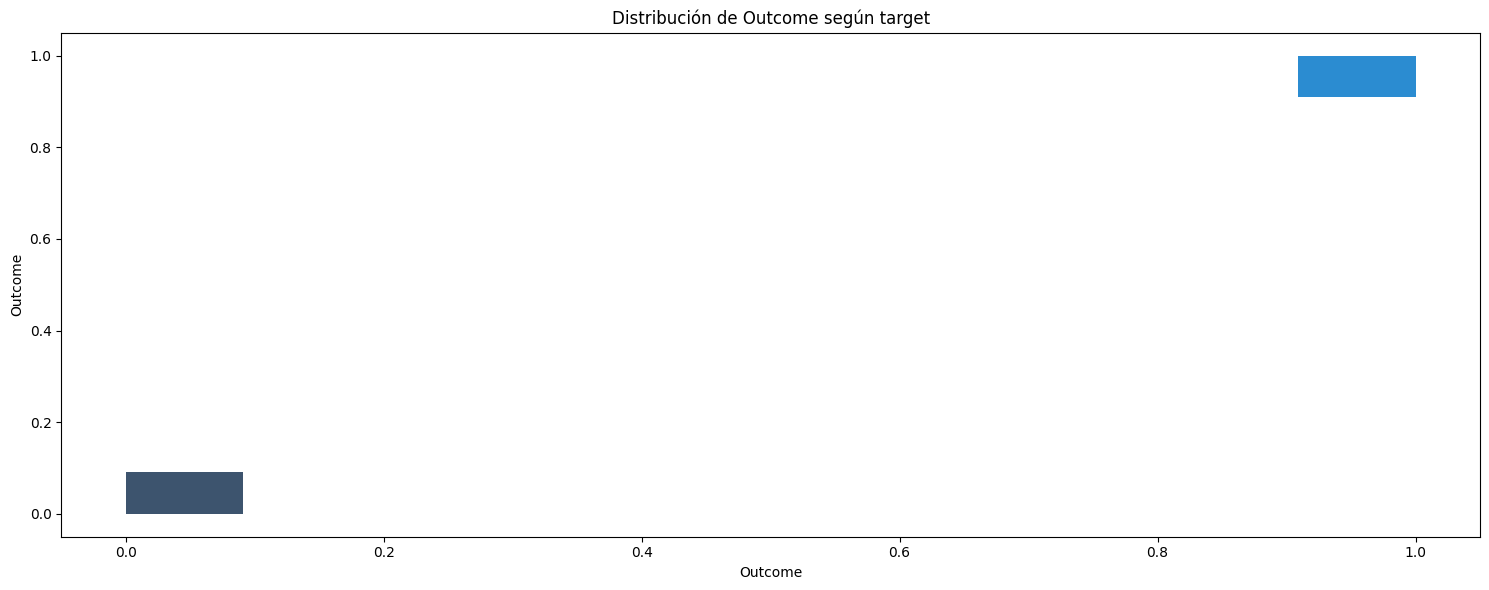

In [200]:
for columna in df:
    plt.figure(figsize=(15,6))
    sns.histplot(data=df, x="Outcome", y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

## Paso 4: Limpieza de Datos

### **Análisis de los registros para el descarte de columnas:**

#### **Valores nulos y duplicados:**

In [201]:
df.duplicated().sum()

np.int64(0)

In [202]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [203]:
insulin_zero = df[df['Insulin']==0]
insulin_zero

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


## Paso 5: Ingeniería de características

### * **Reemplazar valores a 0 en algunas columnas:**

**Justificaciones:**
"SkinThickness", "Insulin", "BloodPressure"

In [210]:
# Fixing columns with missing values
data_zero = ["SkinThickness", "Insulin", "BloodPressure"]

# Replazing zeros with mean of each column
for column in data_zero:
    median_value = df[df[column] != 0][column].median()
    df[column] = df[column].replace(0, median_value)

In [211]:
df[df['Insulin']==0].sum()


Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [212]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,125,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,125,30.1,0.349,47,1


**Observaciones:**

> VAOLRES NULOS Y DUPLICADOS:

### ** Analisis de Outliers**

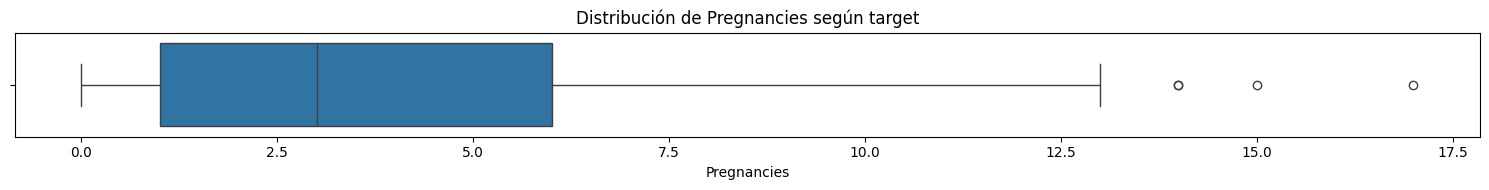

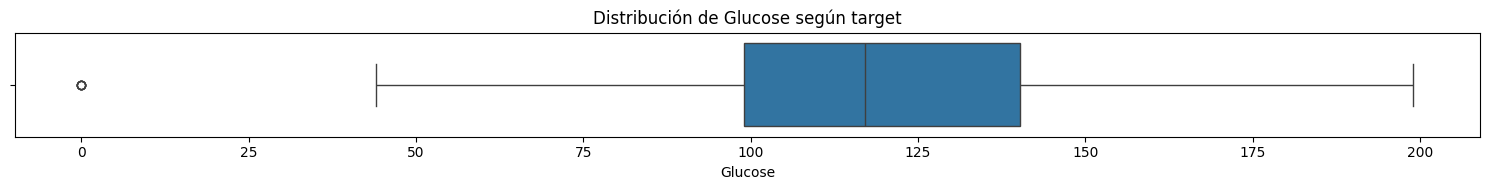

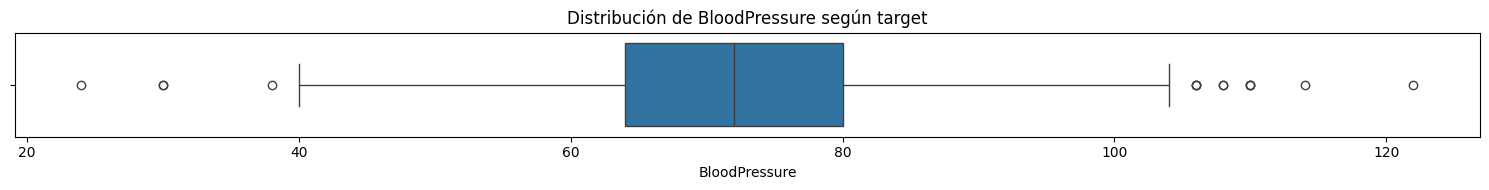

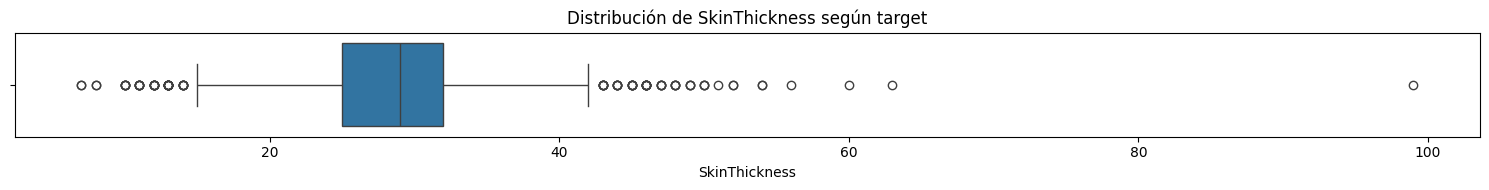

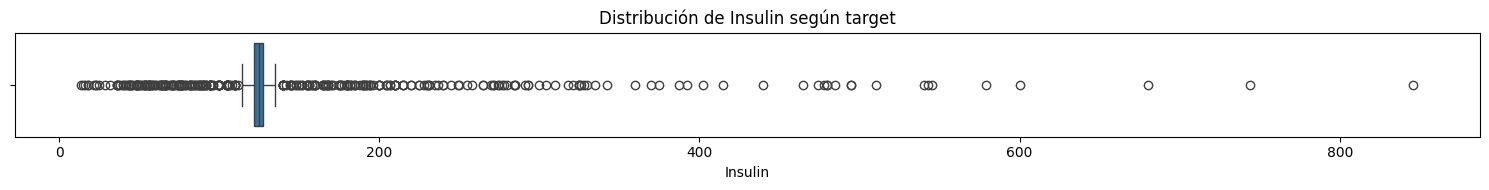

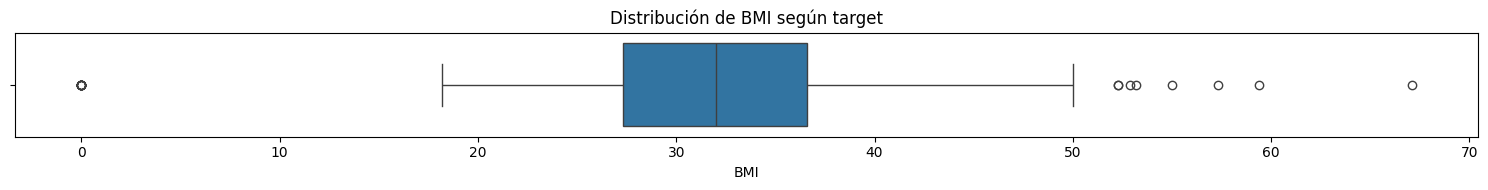

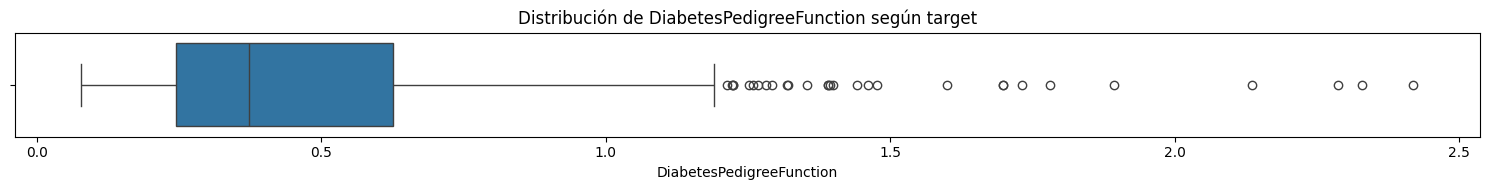

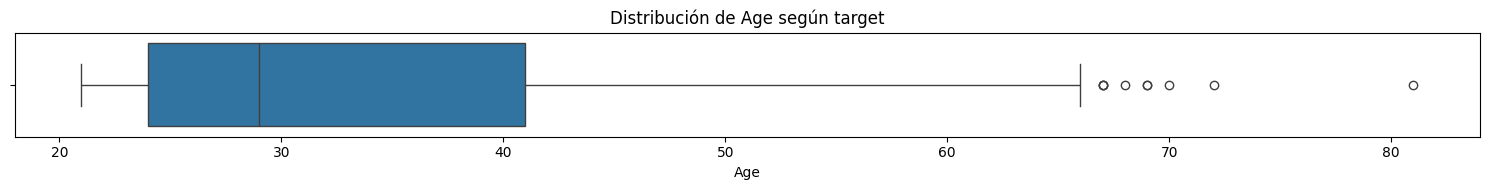

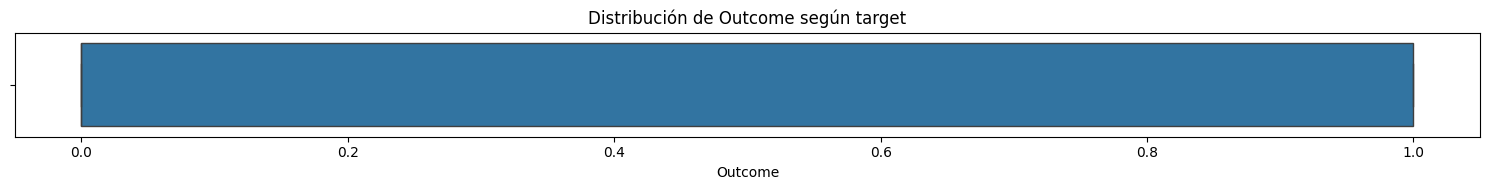

In [207]:
for columna in df:
    plt.figure(figsize=(15,2))
    sns.boxplot(data=df, x=columna, orient="h")
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

**Observaciones:**

Hay columnas que todavñía tienen valores a 0. Son Glucosa y BMI.

In [208]:
df[df['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,125,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,125,32.0,0.389,22,0
349,5,0,80,32,125,41.0,0.346,37,1
502,6,0,68,41,125,39.0,0.727,41,1


In [ ]:
#Los valores BMI a 0 si tienen valores en SkinThickness
df[df['BMI']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,29,125,0.0,0.232,54,1
49,7,105,72,29,125,0.0,0.305,24,0
60,2,84,72,29,125,0.0,0.304,21,0
81,2,74,72,29,125,0.0,0.102,22,0
145,0,102,75,23,125,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,72,29,125,0.0,0.256,25,0
494,3,80,72,29,125,0.0,0.174,22,0
522,6,114,72,29,125,0.0,0.189,26,0
684,5,136,82,29,125,0.0,0.640,69,0


**Conclusiones:**

* Decido no eliminar columnas:  
Todas sí aportan información relevante para el análisis solamente  
'SkinThickness' aunque contiene valores nulos puede compensar los datos a 0 en el BMI  

 ``Pregnancies``, los emabrazos puedes aumentar el riesgo de desarrollar diabetes tipo 2 en el futuro

 ``Glucose``, os resultados de un test de tolerancia a la glucosa determinan si un paciente es diabetico o prediabetico.

 ``Insulin``, la insulina sérica es la insulina presente en la sangre.Si los niveles son bajos entonces indica deficit de produccion de glucosa por lo tanto puede tratarse de diabetes avanzada

 ``DiabetesPedigreeFunction``, riesgo genético de tener diabetes

 ``BMI``, niveles altos indican mayor resistencia a la insulina y diabetes de tipo 2 (índice de masa corporal)

 ``Skinthickness``, según el grosos de la piel podemos detectar el nivel de grasa (obesidad del paciente) que es una condición que puede influir en la diabetes

 ``BloodPressure``, relacionado con BMI, la resistencia a la insulina aumenta los niveles de presión arterial

* **Relleno los valores a 0 de BMI**


In [ ]:
¿?=¿?=?

## Guardado del eda para pasarlo al modelo de arbol de decisiones

In [214]:
# Saving processed data
df.to_csv("../data/processed/diabetes_eda.csv", index=False)